Projet 8: Réalisez une analyse de données en Python

## Milestone 1 - Analyse des données


Dans cette partie nous allons analyser le jeu de données que nous avons à notre disposition. Notre objectif est de comprendre les relations entre les variables, et surtout, celles qui influent sur le prix des transactions immobilières. Grâce à ce travail, nous pourrons ne conserver que les variables qui seront utiles à l'apprentissage de notre algorithme.

1. Type des données

La première étape à réaliser est d'importer les données dans le notebook et d'opérer des transformations sur les variables si celles-ci s'imposent (exemple : nettoyage ou changement de type des variables, etc.).

In [1]:
# On importe les librairies que nous utiliserons pour traiter les données et les visualiser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# télécharger le fichier historique
from google.colab import files
uploaded = files.upload()

Saving historique_immobilier_paris_2017_2021_vdef2.xlsx to historique_immobilier_paris_2017_2021_vdef2.xlsx


In [3]:
# On importe les données dans un dataframe
df_historique= pd.read_excel("historique_immobilier_paris_2017_2021_vdef2.xlsx")
# Afficher le fichier: historique (les 5 premières lignes)
df_historique.head()

,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_postal,nom_commune,code_type_local,type_local,surface_reelle
0,2017-01-03,5.505597e+05,8,RUE DES COUTURES SAINT GERVAIS,75003,Paris 3e Arrondissement,2,Appartement,50
1,2017-01-12,1.576492e+06,32,AV MARCEAU,75008,Paris 8e Arrondissement,2,Appartement,163
2,2017-01-10,6.577574e+05,52,RUE DU FAUBOURG SAINT HONORE,75008,Paris 8e Arrondissement,2,Appartement,66
3,2017-01-10,2.500868e+05,64,RUE DU VERTBOIS,75003,Paris 3e Arrondissement,2,Appartement,22
4,2017-01-13,1.762667e+05,25,RUE DES LAVANDIERES STE OPPORT,75001,Paris 1er Arrondissement,2,Appartement,15


In [4]:
# On vérifie que le type des données attribué par pandas est cohérent (fichier historique)
print( df_historique.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26196 entries, 0 to 26195
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_mutation     26196 non-null  datetime64[ns]
 1   valeur_fonciere   26196 non-null  float64       
 2   adresse_numero    26196 non-null  int64         
 3   adresse_nom_voie  26196 non-null  object        
 4   code_postal       26196 non-null  int64         
 5   nom_commune       26196 non-null  object        
 6   code_type_local   26196 non-null  int64         
 7   type_local        26196 non-null  object        
 8   surface_reelle    26196 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 1.8+ MB
None


2. Regardons les différents types de biens immobiliers que nous avons dans nos données :

In [5]:
print('La liste des différents types de biens immobiliers que nous avons dans les données est :',df_historique['type_local'].unique())

La liste des différents types de biens immobiliers que nous avons dans les données est : ['Appartement' 'Local industriel. commercial ou assimilé']


In [6]:
# les codes des types de biens immobiliers
print(df_historique.groupby('code_type_local')['type_local'].first())


code_type_local
2                                 Appartement
4    Local industriel. commercial ou assimilé
Name: type_local, dtype: object


On observe qu’il existe deux types de biens : l’Appartement (code 2) et le Local industriel, commercial ou assimilé (code 4).

3. le nombre de transactions au total et par type de bien

In [7]:
print('Le nombre de transactions dans les données est :', len(df_historique))

Le nombre de transactions dans les données est : 26196


In [8]:
print('Le nombre de transactions pour les appartements dans les données est :', len(df_historique[df_historique['type_local'] == 'Appartement']))

Le nombre de transactions pour les appartements dans les données est : 24353


In [9]:
print('Le nombre de transactions pour les locaux commerciaux dans les données est :', len(df_historique[df_historique['type_local'] == 'Local industriel. commercial ou assimilé']))

Le nombre de transactions pour les locaux commerciaux dans les données est : 1843


4.l’intervalle de l’historique des données

In [10]:
#On vérifie également la plage de l'historique disponible
print('La première date de transaction dans les données est le :', df_historique['date_mutation'].min().strftime('%d/%m/%Y'))
print('La dernière date de transaction dans les données est le :', df_historique['date_mutation'].max().strftime('%d/%m/%Y'))

La première date de transaction dans les données est le : 02/01/2017
La dernière date de transaction dans les données est le : 31/12/2021


Commençons à analyser les données

Maintenant nous allons analyser les données historiques pour les 2 différents types de biens immobiliers en essayant d'identifier les relations entre les variables. Mais avant cela, il nous faudra pouvoir comparer les biens entre eux, et pour cela nous allons créer une colonne du prix au metre carré.

In [11]:
# Calcul de la colonne prix au mètre carré
df_historique['prix_m2'] =  df_historique['valeur_fonciere'] /  df_historique['surface_reelle']
df_historique[['valeur_fonciere', 'surface_reelle', 'prix_m2']].head()

,valeur_fonciere,surface_reelle,prix_m2
0,5.505597e+05,50,11011.193562
1,1.576492e+06,163,9671.732877
2,6.577574e+05,66,9966.020548
3,2.500868e+05,22,11367.582877
4,1.762667e+05,15,11751.113836


Maintenant, analysons les appartements.

5.L’évolution du prix au mètre carré moyen des appartements dans Paris entre 2017 et 2021 au global

In [12]:
#On retire les colonnes qui sont à priori inutiles ET nous allons nous concentrer sur les appartements dans un premier temps
#Préparons un dataframe en regroupant les prix moyens de ventes des appartements par année avec la surface moyenne associée

# Créer un DataFrame pour les appartements
df_apparts = df_historique[df_historique["type_local"] == "Appartement"].copy()

# Créer un DataFrame regroupant, par année, le prix moyen de vente des appartements ainsi que la surface moyenne associée
df_prix_annee  = df_apparts.groupby(df_apparts['date_mutation'].dt.year.rename('annee')).agg(
    prix_m2_moyen_APP=('prix_m2', 'mean'),
    surface_moyenne_APP=('surface_reelle', 'mean')
).round(2)

print(df_prix_annee)



       prix_m2_moyen_APP  surface_moyenne_APP
annee                                        
2017             9492.86                44.63
2018            10031.40                44.27
2019            10562.71                43.36
2020            10674.87                42.90
2021            10455.60                43.48



On constate qu’il y a une augmentation continue du prix moyen au m² des appartements à Paris entre 2017 et 2020, passant d’environ 9493 €/m² à 10675 €/m², avant de connaître une légère baisse en 2021 à 10 455,60 €/m².

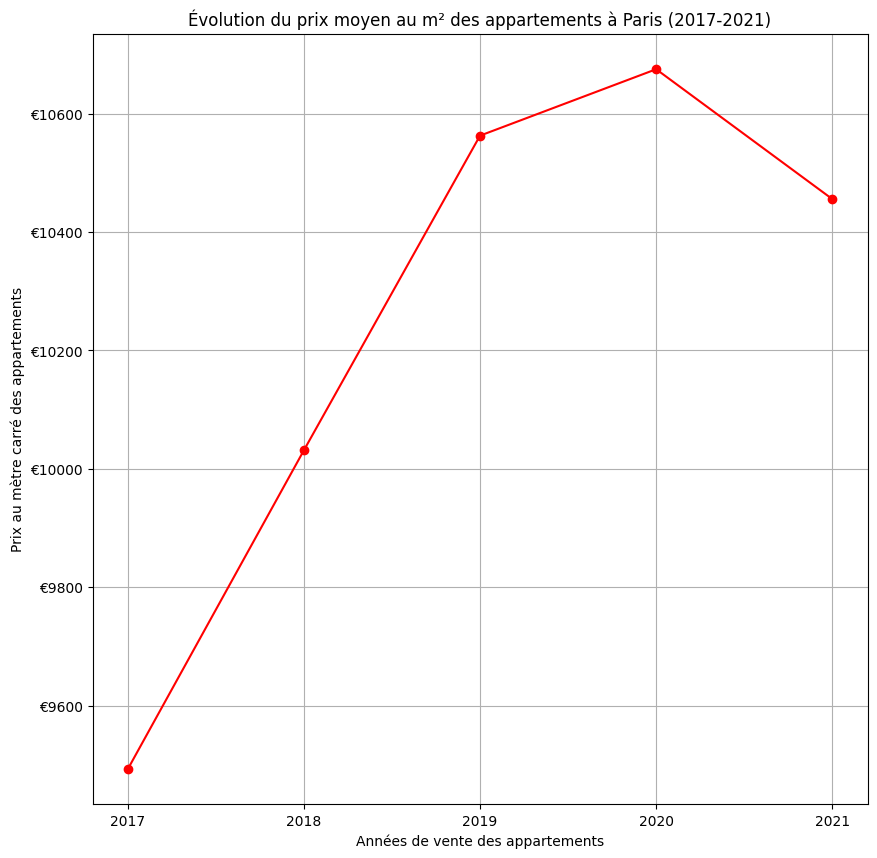

In [13]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(10,10))

# tracer les années et le prix moyen au m²
plt.plot(df_prix_annee .index, df_prix_annee ['prix_m2_moyen_APP'], marker='o', color='red')

plt.xlabel('Années de vente des appartements')
plt.ylabel('Prix au mètre carré des appartements')

formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid()
plt.title('Évolution du prix moyen au m² des appartements à Paris (2017-2021)')
plt.xticks(df_prix_annee.index)   # affichage des années entières
plt.show()

6. les différences de prix au mètre carré moyen des appartements par arrondissement

Maintenant nous allons chercher à afficher l'évolution des prix par arrondissement. Vérifions la liste des arrondissements que nous avons dans nos données. Normalement à Paris nous avons 20 codes postaux différents, 1 par arrondissement allant de 75001 à 75020.



In [14]:
#Liste des codes postaux dans nos données.
codes_postaux = sorted(df_apparts['code_postal'].unique())
print('Codes postaux présents dans les données :', codes_postaux)
print('Nombre d\'arrondissements :', len(codes_postaux))

Codes postaux présents dans les données : [np.int64(75001), np.int64(75002), np.int64(75003), np.int64(75004), np.int64(75005), np.int64(75006), np.int64(75007), np.int64(75008), np.int64(75009), np.int64(75010), np.int64(75011), np.int64(75012), np.int64(75013), np.int64(75014), np.int64(75015), np.int64(75016), np.int64(75017), np.int64(75018), np.int64(75019), np.int64(75020)]
Nombre d'arrondissements : 20


In [15]:
# Création du DataFrame pour visualiser l'évolution des prix par arrondissement
# DataFrame regroupant les prix moyens au m² des ventes par arrondissement(code postal)
prix_apparts_arrondissement = df_apparts.groupby('code_postal').agg(prix_m2_moyen_APP=('prix_m2', 'mean')).round(2)
print(prix_apparts_arrondissement)

             prix_m2_moyen_APP
code_postal                   
75001                 12833.90
75002                 11667.52
75003                 12465.63
75004                 13123.57
75005                 12295.09
75006                 13143.51
75007                 12649.30
75008                 10948.82
75009                 10476.60
75010                  9655.44
75011                  9979.58
75012                  9206.67
75013                  8976.32
75014                  9691.58
75015                  9636.22
75016                 10487.18
75017                 10085.24
75018                  9442.45
75019                  8535.59
75020                  8762.77


In [16]:
# Création du DataFrame pour visualiser l'évolution des prix par arrondissement et année
df_prix_arrondissement_annee = df_apparts.groupby(['code_postal', df_apparts['date_mutation'].dt.year]).agg(
    prix_m2_moyen_APP=('prix_m2', 'mean')
).round(2)

     # Renommer l'index de l'année pour plus de clarté
df_prix_arrondissement_annee.index.set_names(['code_postal', 'annee'], inplace=True)

     # Afficher un aperçu
df_prix_arrondissement_annee.head(10)

prix_m2_moyen_APP
code_postal annee                   
75001       2017            11762.71
            2018            12621.23
            2019            13269.26
            2020            13405.99
            2021            13379.50
75002       2017            10920.13
            2018            11309.46
            2019            12150.54
            2020            12181.59
            2021            11773.45

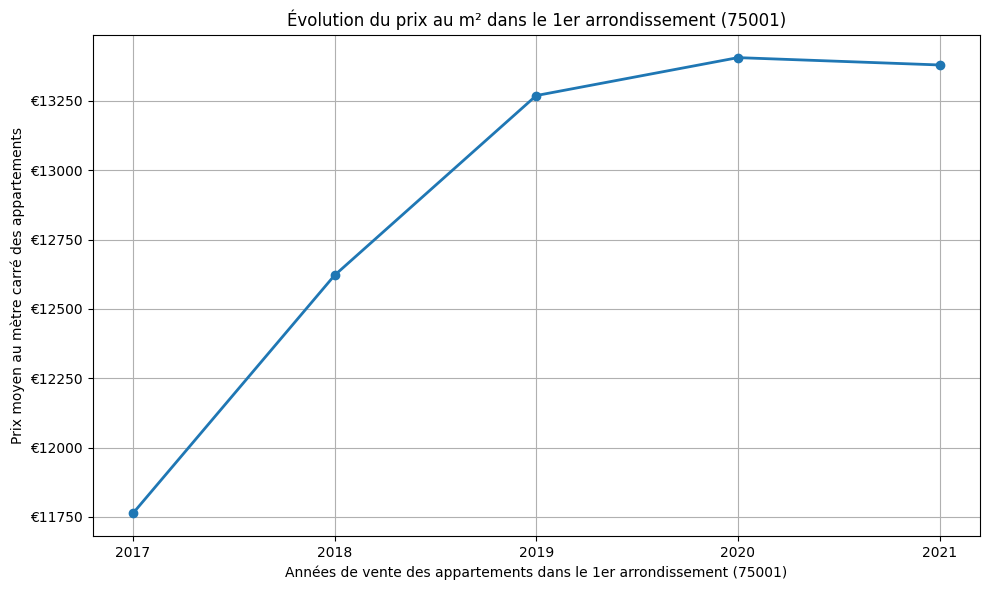

In [17]:
# Création du graphique
# Extraire uniquement les années et les prix pour le 1er arrondissement (75001)
annees = ['2017','2018','2019','2020','2021']
prix_75001 = df_prix_arrondissement_annee.loc[75001].prix_m2_moyen_APP.values  # colonne prix_m2_moyen

plt.figure(figsize=(10,6))
plt.plot(annees, prix_75001, marker='o', linewidth=2)

# Ajouter labels et formatage
plt.xlabel('Années de vente des appartements dans le 1er arrondissement (75001)')
plt.ylabel('Prix moyen au mètre carré des appartements')

# Formater l'axe Y avec le symbole €
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(True)
plt.title('Évolution du prix au m² dans le 1er arrondissement (75001)')
plt.tight_layout()
plt.show()



Nous allons ajouter à cette visualisation tous les autres arrondissement avec une couleur différente.

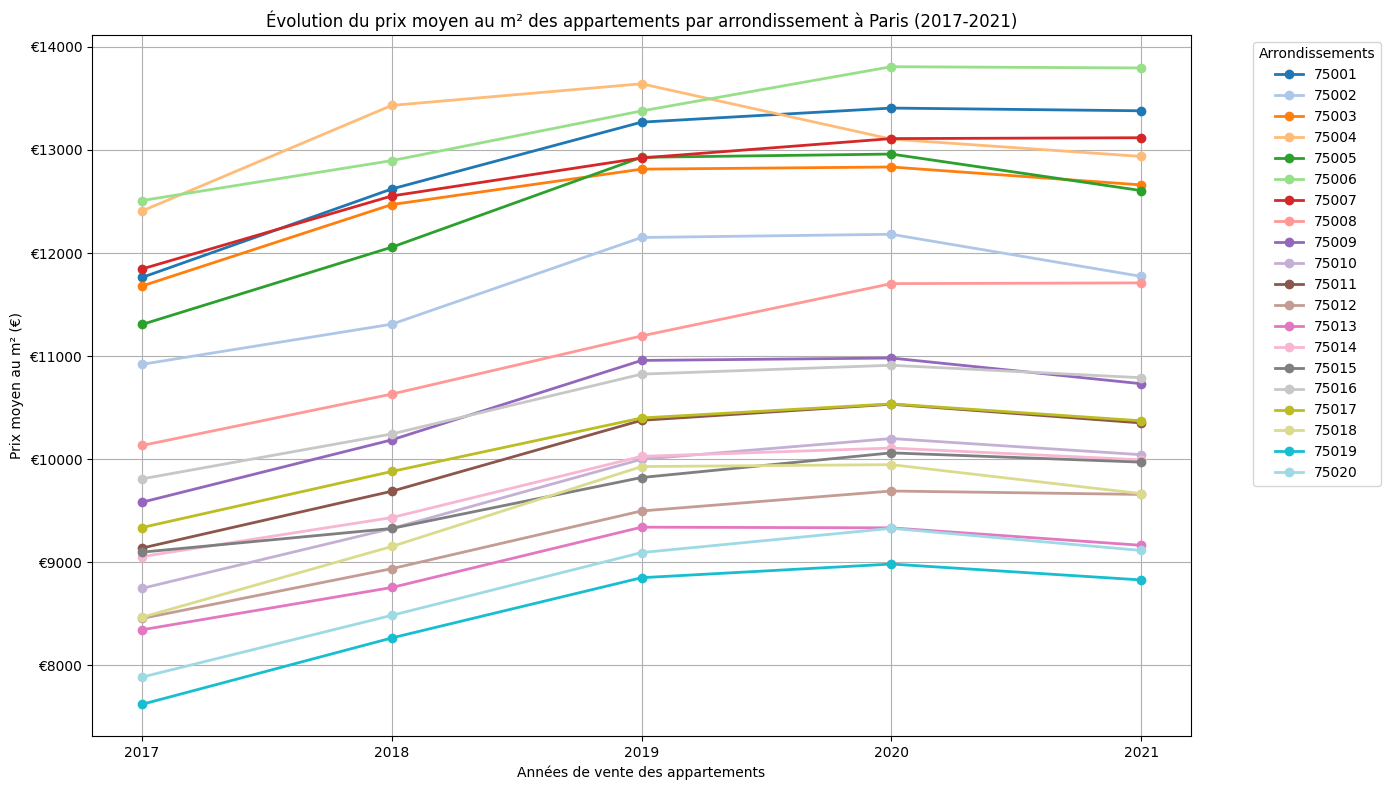

In [18]:
#On affiche l'évolution du prix au m² par arrondissement dans Paris
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns  # pour obtenir des couleurs distinctes

# Liste des 20 codes postaux (arrondissements de Paris)
arrondissements = sorted(df_apparts['code_postal'].unique())

# Créer une palette de 20 couleurs distinctes
colors = sns.color_palette("tab20", 20)

# Création du graphique
plt.figure(figsize=(14,8))

for i, cp in enumerate(arrondissements):
    # Extraire les années et prix moyens pour l'arrondissement
    annees = df_prix_arrondissement_annee.loc[cp].index.astype(str)
    prix_cp = df_prix_arrondissement_annee.loc[cp].prix_m2_moyen_APP.values

    # Tracer la courbe avec une couleur unique
    plt.plot(annees, prix_cp, marker='o', color=colors[i], linewidth=2, label=str(cp))

# Ajouter labels et titre
plt.xlabel("Années de vente des appartements")
plt.ylabel("Prix moyen au m² (€)")
plt.title("Évolution du prix moyen au m² des appartements par arrondissement à Paris (2017-2021)")

# Formater l'axe Y avec le symbole €
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(True)

# Légende à droite pour ne pas cacher les courbes
plt.legend(title="Arrondissements", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

On observe que, globalement, tous les arrondissements de Paris suivent une tendance haussière entre 2017 et 2020, suivie d’une légère baisse ou stabilisation en 2021. Les arrondissements centraux (75006, 75004, 75001, 75007) affichent les prix les plus élevés (> 12 000 €/m²), tandis que les arrondissements périphériques (75018, 75019, 75020) restent les moins chers (< 9 500 €/m²

7. les prix au mètre carré par transaction dans un arrondissement

In [19]:
#Vérifions le nombre de transaction dans le 6ème car le prix semble élevé
# Filtrer les transactions dans le 6ème arrondissement
transactions_75006 = df_apparts[df_apparts['code_postal'] == 75006]

# Nombre total de transactions
nb_transactions = len(transactions_75006)

print(f"Nombre de transactions dans le 6ème arrondissement (75006) : {nb_transactions}")

Nombre de transactions dans le 6ème arrondissement (75006) : 709


On constate que le 6ème arrondissement dispose d'un nombre significatif de transactions 709 et affiche le prix au m² le plus élevé de Paris (~13 000€/m² en moyenne), ce qui est cohérent avec le prestige de cet arrondissement.

Affichons l'historique des transactions pour visualiser la dispersion des données :

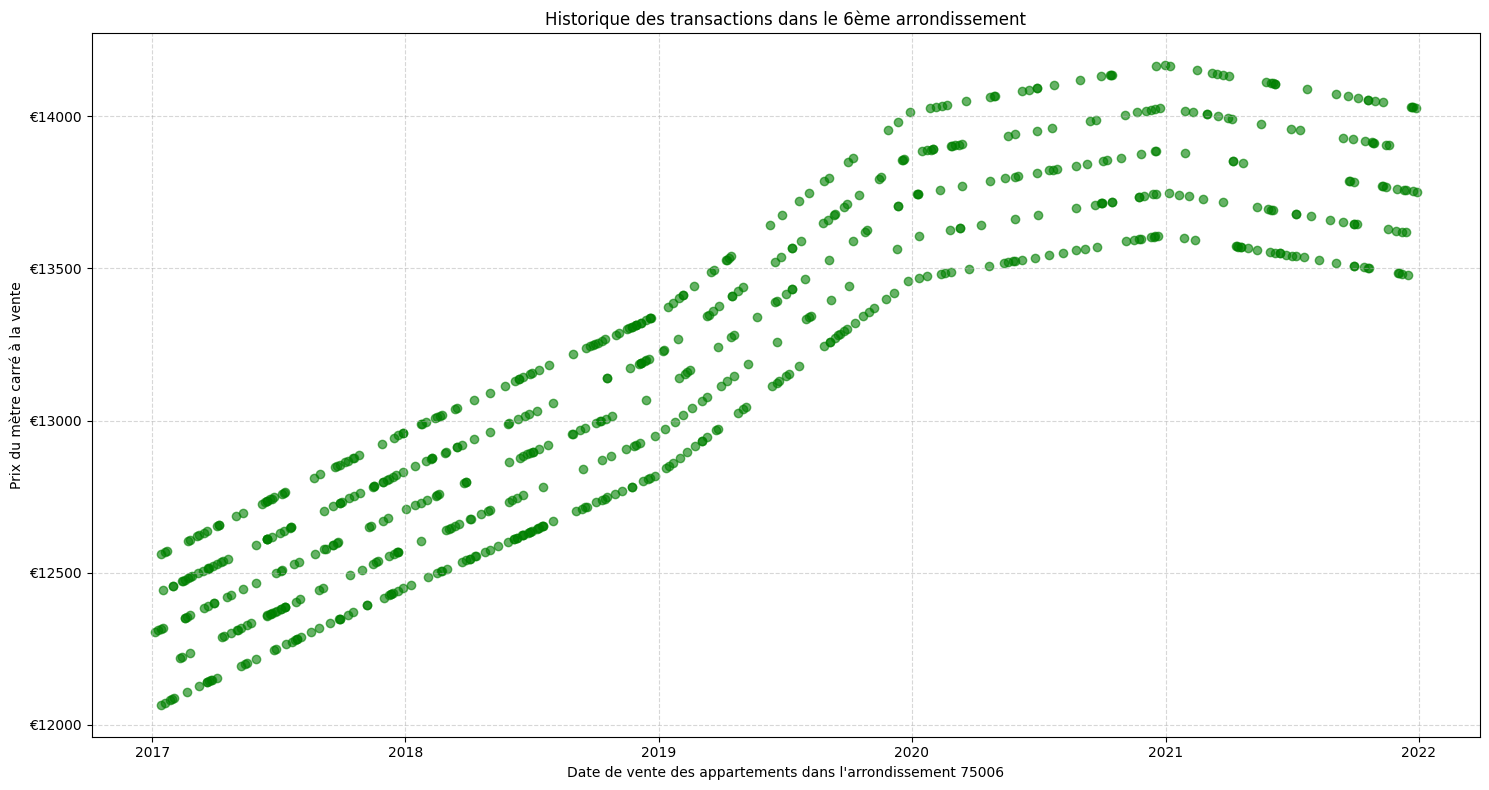

In [20]:
#Affichons l'historique des transactions pour visualiser la dispersion des données
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

cp = 75006
# Filtrer les transactions du 6ème arrondissement
transactions_75006 = df_apparts[df_apparts['code_postal'] == cp]
plt.figure(figsize=(15,8))

# Scatter plot des prix au m²
plt.scatter(transactions_75006['date_mutation'], transactions_75006['prix_m2'],
            color='green', alpha=0.6)


# Labels et titre
plt.xlabel("Date de vente des appartements dans l'arrondissement 75006")
plt.ylabel("Prix du mètre carré à la vente")
plt.title("Historique des transactions dans le 6ème arrondissement")

# Formater l'axe Y en €
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)

# Grille
plt.grid(which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Ce nuage de points montre les ventes dans le 6ᵉ arrondissement. Chaque point correspond à une transaction, ce qui permet de voir comment les prix évoluent dans le temps.
On observe une  hausse entre 2017 et 2020, d’environ 12 000 €/m² à près de 14 000 €/m². À partir de 2020, les prix se stabilisent entre 13 000 et 14 000 €/m², avec une légère baisse à la fin de 2021, ce qui traduit un ralentissement du marché.
On voit aussi une variabilité entre les transactions, et ça est liée à la différence de surface, au standing et aux caractéristiques des appartements.

Pour nous rassurer sur la relation entre les données nous allons utiliser un test statistique de corrélation.

8. Vérification de la relation entre le prix au m² et la date dans le 6ème arrondissement par le calcul du coefficient de corrélation de Pearson


  Pour cette distribution nous allons calculer le coefficient de corrélation de Pearson. La relation entre le prix au metre carré et la date n'est pas forcément linéaire mais elle s'en rapproche suffisamment pour que cette analyse soit pertinente (voir l'évolution du prix au metre carré globale montrée plus haut, on a presque une droite sauf entre 2020 et 2021). Ce qui nous interesse c'est de prouver que le temps a une influence sur le prix.

In [21]:
# calcule  le coefficient de corrélation de Pearson entre le prix au m² et la date pour les appartements situés dans le 6ᵉ arrondissement.
import pandas as pd
from scipy import stats

cp = 75006

# Filtrer les transactions
transactions_75006 = df_apparts[df_apparts['code_postal'] == cp].copy()

# Transformer la date en nombre pour le calcul(En nombre de jours)
jours = transactions_75006['date_mutation'].map(pd.Timestamp.toordinal)


# Calcul du coefficient de corrélation de Pearson
corr_pearson, p_value = stats.pearsonr(jours, transactions_75006['prix_m2'])

print("Coefficient de corrélation de Pearson :", corr_pearson)
print("p-value :", p_value)

Coefficient de corrélation de Pearson : 0.903844603149148
p-value : 7.108378962571935e-263


Le coefficient de corrélation de Pearson entre la date de transaction et le prix au m² dans le 6ᵉ arrondissement est de 0.90, ce qui indique une très forte corrélation positive.
La p-value, égale à (7.10e-263 ~ 0.00), est extrêmement faible (< 0.05), ce qui confirme que cette relation est statistiquement significative et pas due au hasard.
On peut donc conclure que le prix au m² des appartements dans le 6ᵉ arrondissement a fortement augmenté au fil du temps.

9. Vérification de la relation entre la valeur fonciere et la surface

In [22]:
# Vérification de la relation entre la valeur fonciere et la surface
from scipy import stats
# Calcul de la corrélation de Spearman
corr_spearman, p_value = stats.spearmanr(df_apparts['valeur_fonciere'], df_apparts['surface_reelle'])
#corr_spearman, p_value = stats.spearmanr(df_apparts['prix_m2'], df_apparts['surface_reelle'])
print("Coefficient de corrélation de Spearman :", corr_spearman)
print("p-value :", p_value)

Coefficient de corrélation de Spearman : 0.9766286639807918
p-value : 0.0


Le coefficient de corrélation de Spearman entre la valeur foncière (le prix au mètre carré ) et la surface des appartements est de 0.98, ce qui indique une corrélation positive très forte.
La p-value, égale à 0.0, est extrêmement faible (< 0.05), confirmant que cette relation est statistiquement significative et pas due au hasard.
On peut donc conclure que la valeur des appartements augmente fortement avec leur surface.

Supplément : visualisation de la droite de corrélation

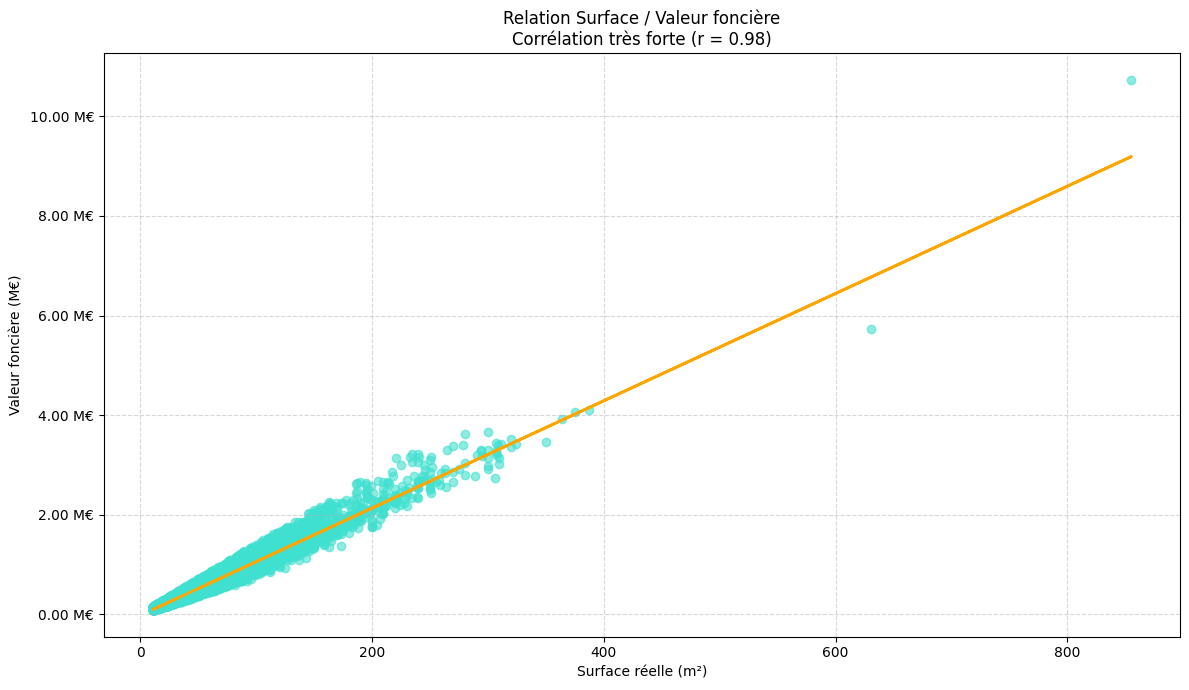

In [23]:
# Entre la valeur foncière et la surface, afin d’analyser la relation entre ces deux variables à l’aide de la droite de corrélation.
plt.figure(figsize=(12,7))
# Scatter plot
plt.scatter(df_apparts['surface_reelle'], df_apparts['valeur_fonciere'] / 1_000_000, color='turquoise', alpha=0.6)

# Droite de corrélation (régression linéaire)
x = df_apparts['surface_reelle']
y = df_apparts['valeur_fonciere'] / 1_000_000   # en millions €

coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)
plt.plot(x, poly(x),color='orange', linewidth=2)

# Labels et titre
plt.xlabel("Surface réelle (m²)")
plt.ylabel("Valeur foncière (M€)")
plt.title("Relation Surface / Valeur foncière\nCorrélation très forte (r = 0.98)")

# Format de l’axe Y en millions €
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f M€'))

# Grille
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Regardons maintenant si le type de bien à une influence sur le prix au metre carré également.

10. Analyse des locaux industriels, commerciaux et assimilés

In [24]:
# On crée un dataset qui ne contient que les locaux commerciaux
df_commerces = df_historique[df_historique['type_local'] == 'Local industriel. commercial ou assimilé'].copy()

# Vérifier le nombre de transactions
print("Nombre de transactions de locaux commerciaux :", len(df_commerces))
df_commerces.head()

Nombre de transactions de locaux commerciaux : 1843


,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_postal,nom_commune,code_type_local,type_local,surface_reelle,prix_m2
18,2017-02-01,3.113277e+06,65,RUE DE TURBIGO,75003,Paris 3e Arrondissement,4,Local industriel. commercial ou assimilé,250,12453.109192
29,2017-02-17,1.164375e+06,17,RUE DU PONT AUX CHOUX,75003,Paris 3e Arrondissement,4,Local industriel. commercial ou assimilé,95,12256.581685
34,2017-02-20,3.802522e+05,10,RUE CAFFARELLI,75003,Paris 3e Arrondissement,4,Local industriel. commercial ou assimilé,31,12266.199603
91,2017-03-09,3.623842e+05,33,RUE DE RICHELIEU,75001,Paris 1er Arrondissement,4,Local industriel. commercial ou assimilé,29,12496.006027
109,2017-03-29,3.159072e+05,130,RUE VIEILLE DU TEMPLE,75003,Paris 3e Arrondissement,4,Local industriel. commercial ou assimilé,25,12636.289027


In [25]:
# Préparons un dataframe en regroupant les prix au metre carré moyens des ventes par année (locaux industriels, commerciaux et assimilés)
prix_commerces_annee = df_commerces.groupby(
    df_commerces['date_mutation'].dt.year.rename('annee')
).agg(prix_m2_COM=('prix_m2', 'mean')).round(2)

# Afficher le résultat
print(prix_commerces_annee)


       prix_m2_COM
annee             
2017      10949.91
2018      11569.50
2019      11960.13
2020      11966.47
2021      12006.49


In [26]:
#Avant de réaliser le graphe, on crée un DataFrame prix_apparts_annee
# DataFrame regroupant les prix moyens au m² des ventes par année (appartements)
prix_apparts_annee = df_apparts.groupby(df_apparts['date_mutation'].dt.year.rename('annee')).agg(
    prix_m2_moyen_APP=('prix_m2', 'mean')).round(2)
# Afficher le résultat
print(prix_apparts_annee)

       prix_m2_moyen_APP
annee                   
2017             9492.86
2018            10031.40
2019            10562.71
2020            10674.87
2021            10455.60


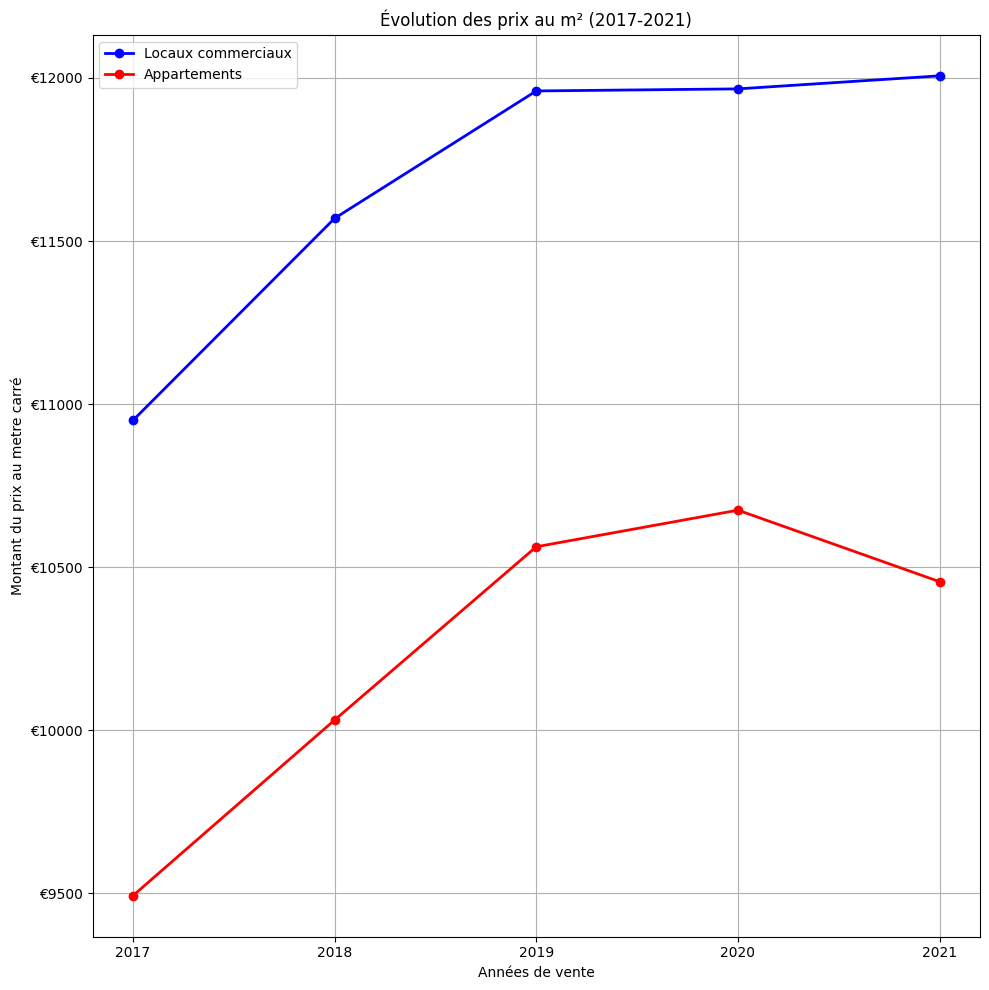

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Extraire les années et les prix moyens
annees = prix_commerces_annee.index.astype(str)  # Les années communes aux deux DataFrames
prix_commerces = prix_commerces_annee['prix_m2_COM'].values
prix_appartements = prix_apparts_annee['prix_m2_moyen_APP'].values

# Création du graphique
plt.figure(figsize=(10,10))
plt.plot(annees, prix_commerces, label='Locaux commerciaux', color='blue', marker='o', linewidth=2)
plt.plot(annees, prix_appartements, label='Appartements', color='red', marker='o', linewidth=2)

# Labels et titre
plt.xlabel('Années de vente')
plt.ylabel('Montant du prix au metre carré')
plt.title('Évolution des prix au m² (2017-2021)')

# Légende (affiche ces noms  sur le graphique ( en haut à gauche.)
plt.legend()

# Formater l’axe Y avec le symbole €
formatter = ticker.FormatStrFormatter('€%d')
plt.gca().yaxis.set_major_formatter(formatter)

plt.grid(True)
plt.tight_layout()
plt.show()

On observe que le prix au mètre carré des locaux commerciaux a augmenté régulièrement entre 2017 et 2021, passant d’environ 10 000 à 12 000 euros, avec une légère pause en 2020, avant de reprendre une progression modérée en 2021. Par ailleurs, le prix au mètre carré des locaux commerciaux est systématiquement plus élevé que celui des appartements sur toute la période 2017‑2021, confirmant l’attractivité et la valeur supérieure du segment commercial par rapport au résidentiel.


Après ces analyses, nous pouvons conclure que les dimensions à utiliser pour prédire le prix au m² sont :

la surface du bien immobilier,
la date considérée,
la localisation (code_postal),
le type de bien.

## Milestone 2 - Entraînement de l'algorithme de régression linéaire

Dans cette section nous allons maintenant entrâiner un algorithme à prédire la valeur fonciere d'un bien immobilier. Pour cela nous allons utiliser l'algorithme de régression linéaire.

On commence par préparer nos données en transformant les colonnes catégoriques du code postal et du type de local grâce au one hot encoder (sklearn) / get_dummies (pandas)

In [28]:
#Sélection des variables utiles
#on crée un DataFrame avec uniquement les colonnes nécessaires
df_model = df_historique[['code_postal','type_local','surface_reelle','date_mutation','valeur_fonciere']].copy()

# Transformant les colonnes catégoriques du code postal et du type de local grâce au one hot encoder (sklearn) / get_dummies (pandas)
# en colonnes binaires
df_model_encoded = pd.get_dummies(df_model, columns=['code_postal', 'type_local'], dtype=int)

#Transformation de la date: la régression linéaire ne comprend pas le format datetime
df_model_encoded['date_mutation']=df_model_encoded['date_mutation'].astype('datetime64[s]').astype('int64') / 10**9

print(f"Nombre de colonnes après encodage : {df_model_encoded.shape[1]}")
df_model_encoded.head()


Nombre de colonnes après encodage : 25


,surface_reelle,date_mutation,valeur_fonciere,code_postal_75001,code_postal_75002,code_postal_75003,code_postal_75004,code_postal_75005,code_postal_75006,code_postal_75007,...,code_postal_75013,code_postal_75014,code_postal_75015,code_postal_75016,code_postal_75017,code_postal_75018,code_postal_75019,code_postal_75020,type_local_Appartement,type_local_Local industriel. commercial ou assimilé
0,50,1.483402,5.505597e+05,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,163,1.484179,1.576492e+06,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,66,1.484006,6.577574e+05,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,22,1.484006,2.500868e+05,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,15,1.484266,1.762667e+05,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


On utilise le train_test_split pour prélever un tiers de nos données (33%) et les garder de côté. Nous allons entraîner notre algorithme sur le reste des données et puis mesurer notre erreur moyenne en pourcentage de la valeur foncière

In [29]:
# Définition des variables
from sklearn.model_selection import train_test_split
X = df_model_encoded.drop(columns=['valeur_fonciere'])               # variables explicatives(features) [['date_mutation','code_postal','type_local','surface_reelle']]
y = df_model_encoded['valeur_fonciere']                              # Variable cible (target) à prédire: valeur_fonciere

# Séparation des données: entre échantillon d'entraînement et de test On garde 33% des données pour le test
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.33 ,random_state=42)

#Le nombre de lignes et colonnes dans l’échantillon d’entraînement et  dans l’échantillon de test
print(X_train.shape, X_test.shape)


(17551, 24) (8645, 24)


In [30]:
#conversion des données en str
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

In [31]:
#Création du modèle et Entraînement(fit)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [32]:
# Effectuer la prédiction
y_pred = model.predict(X_test)

# Évaluer l'erreur moyenne en pourcentage
import numpy as np
erreur = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"Erreur moyenne en pourcentage : {erreur:.2f}%")

Erreur moyenne en pourcentage : 9.53%


Notre algorithme fait donc environ 9.53 % d'erreur en moyenne sur la prédiction de la valeur foncière.

Le modèle de régression linéaire permet de prédire la valeur foncière des biens immobiliers avec une erreur moyenne d’environ 9.53 %, ce qui indique une bonne capacité de prédiction.
Cela montre qu'il existe une relation importante entre la valeur foncière et les variables utilisées dans le modèle, notamment la surface du bien, le code postal, le type de local et l’année de transaction.
Cependant, ce modèle reste relativement simple et ne prend pas en compte certains facteurs importants pouvant influencer le prix immobilier.

Comment aller plus loin

Pour améliorer les performances du modèle, il serait possible :

prédit le prix au m²

d’ajouter d’autres variables explicatives comme le nombre de pièces, l’étage, la localisation plus précise ou la proximité des transports

d’utiliser des modèles de machine learning plus performants comme Random Forest, Gradient Boosting ou XGBoost




## Milestone3 : Prédiction de la valorisation future de portefeuille et présentation des résultats

Nous avons récupéré le fichier avec le portefeuille des actifs de la société. Nous allons l'importer puis effectuer la prédiction et statuer sur la branche qui, selon notre prédiction, aura le plus de valeur à la date demandée c'est à dire au 31 décembre 2022.
Petite précision, nous souhaitons continuer à utiliser la surface réelle pour faire les calculs et pas la surface carrez.

In [33]:
#On importe les données dans un dataframe
# 1)télécharger les fichiers
from google.colab import files
uploaded = files.upload()

Saving portefeuille_actifs+(3).xlsx to portefeuille_actifs+(3).xlsx


In [34]:
# 2)Charger le fichier Excel dans un DataFrame
df_portefeuille = pd.read_excel("portefeuille_actifs+(3).xlsx")

#Infos générales du portefeuille
print( df_portefeuille.info())
print(f"df_Portefeuille : {len(df_portefeuille)} biens immobiliers")
print(f"Types de biens : {df_portefeuille['type_local'].value_counts().to_dict()}")
df_portefeuille.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   adresse_numero             275 non-null    int64  
 1   adresse_nom_voie           275 non-null    object 
 2   code_postal                275 non-null    int64  
 3   code_commune               275 non-null    int64  
 4   nom_commune                275 non-null    object 
 5   surface_carrez             275 non-null    float64
 6   code_type_local            275 non-null    int64  
 7   type_local                 275 non-null    object 
 8   surface_reelle_bati        275 non-null    int64  
 9   nombre_pieces_principales  275 non-null    int64  
 10  longitude                  275 non-null    float64
 11  latitude                   275 non-null    float64
dtypes: float64(3), int64(6), object(3)
memory usage: 25.9+ KB
None
df_Portefeuille : 275 biens immobiliers
Typ

,adresse_numero,adresse_nom_voie,code_postal,code_commune,nom_commune,surface_carrez,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,longitude,latitude
0,127,RUE SAINT-DENIS,75001,75101,Paris 1er Arrondissement,16.41,2,Appartement,25,1,2.349593,48.863227
1,62,RUE NOTRE-DAME DE NAZARETH,75003,75103,Paris 3e Arrondissement,20.47,2,Appartement,22,1,2.356977,48.867907
2,62,RUE DE TURENNE,75003,75103,Paris 3e Arrondissement,64.48,2,Appartement,65,3,2.364855,48.859318
3,32,AV GEORGE V,75008,75108,Paris 8e Arrondissement,63.29,2,Appartement,74,2,2.301586,48.868893
4,152,BD HAUSSMANN,75008,75108,Paris 8e Arrondissement,20.58,2,Appartement,22,1,2.311643,48.875490


Nous avons la liste des biens immobiliers de l'entreprise. Pour effectuer une prédiction, nous devons mettre ce fichier au même format que le dataframe que nous avons utilisé lors de l'entraînement de l'algorithme.

In [35]:
# Avant de commencer, on prépare le DataFrame portefeuille
# en gardant uniquement les variables utiles
df_portefeuille_model = df_portefeuille[['code_postal', 'type_local', 'surface_reelle_bati']].copy()

#On réutilise les mêmes fonctions pour faire le one hot encoding des variables catégorielles
df_portefeuille_encoded = pd.get_dummies(df_portefeuille_model,columns=['code_postal', 'type_local'], dtype=int)

# Renommer la colonne surface_reelle_bati en surface_reelle comme le model historique
df_portefeuille_encoded = df_portefeuille_encoded.rename(columns={'surface_reelle_bati': 'surface_reelle'})

# On importe la librairie datetime pour pouvoir créer une colonne timestamp avec la date du 31 décembre 2022 pour la prédiction
# 1)crier une colonne
import datetime as dt
df_portefeuille_encoded['date_mutation'] = dt.datetime(2022, 12, 31)
# 2)Convertir en numérique
df_portefeuille_encoded['date_mutation']=df_portefeuille_encoded['date_mutation'].astype('datetime64[s]').astype('int64') / 10**9

# Afficher le résultat
df_portefeuille_encoded.head()

,surface_reelle,code_postal_75001,code_postal_75002,code_postal_75003,code_postal_75004,code_postal_75005,code_postal_75006,code_postal_75007,code_postal_75008,code_postal_75009,...,code_postal_75014,code_postal_75015,code_postal_75016,code_postal_75017,code_postal_75018,code_postal_75019,code_postal_75020,type_local_Appartement,type_local_Local industriel. commercial ou assimilé,date_mutation
0,25,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1.672445
1,22,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1.672445
2,65,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1.672445
3,74,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,1.672445
4,22,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,1.672445


In [36]:
# Aligner les colonnes avec celles du modèle entraîné : Il est probable que certaines colonnes (ex : code_postal ou type_local) ne soient pas présentes dans le portefeuille. Il faut donc aligner les colonnes avec celles du modèle entraîné :
# Ajouter les colonnes manquantes avec des zéros (le cas échéant)
for col in X_train.columns:
    if col not in df_portefeuille_encoded.columns:
        df_portefeuille_encoded[col] = 0

# Réordonner les colonnes pour correspondre exactement à X_train
df_portefeuille_encoded = df_portefeuille_encoded[X_train.columns]

In [37]:
#Conversion du dataframe en str
df_portefeuille_encoded = df_portefeuille_encoded.astype(str)


Notre dataframe est prêt à être utilisé par notre algorithme de prédiction.

In [38]:
# Prédiction de la valeur foncière
df_portefeuille['valeur_fonciere_predite'] = model.predict(df_portefeuille_encoded)

# Vérifier le résultat
df_portefeuille.head()

,adresse_numero,adresse_nom_voie,code_postal,code_commune,nom_commune,surface_carrez,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,longitude,latitude,valeur_fonciere_predite
0,127,RUE SAINT-DENIS,75001,75101,Paris 1er Arrondissement,16.41,2,Appartement,25,1,2.349593,48.863227,431444.348989
1,62,RUE NOTRE-DAME DE NAZARETH,75003,75103,Paris 3e Arrondissement,20.47,2,Appartement,22,1,2.356977,48.867907,368861.389873
2,62,RUE DE TURENNE,75003,75103,Paris 3e Arrondissement,64.48,2,Appartement,65,3,2.364855,48.859318,827086.357977
3,32,AV GEORGE V,75008,75108,Paris 8e Arrondissement,63.29,2,Appartement,74,2,2.301586,48.868893,878984.851836
4,152,BD HAUSSMANN,75008,75108,Paris 8e Arrondissement,20.58,2,Appartement,22,1,2.311643,48.875490,324852.332269


Maintenant nous allons comparer la valorisation prédite pour les deux segments.

In [39]:
# Valorisation du portefeuille sur le segment des particuliers
df_part = df_portefeuille[df_portefeuille["type_local"] == "Appartement"]

# Somme des valeurs prédites uniquement pour le segment particuliers
val_part = round(df_part["valeur_fonciere_predite"].sum() / 1_000_000, 2)
print(f"La valorisation du segment particuliers est : {val_part} millions d'euros")

La valorisation du segment particuliers est : 71.05 millions d'euros


In [40]:
# Valorisation du portefeuille sur le segment corporate
df_corp = df_portefeuille[df_portefeuille["type_local"] == "Local industriel. commercial ou assimilé"]

# Somme des valeurs prédites uniquement pour le segment corporate
val_corp = round(df_corp["valeur_fonciere_predite"].sum() / 1_000_000, 2)
print(f"La valorisation du segment corporate est : {val_corp} millions d'euros")

La valorisation du segment corporate est : 97.97 millions d'euros


Conclusions sur la valorisation des segments :
Selon la prédiction du modèle de régression linéaire, le segment corporate est le plus valorisé avec 97,97 millions d’euros, contre 71,05 millions d’euros pour le segment particuliers. Cela montre que les biens destinés aux entreprises représentent la plus grande valeur totale dans le portefeuille à la date du 31 décembre 2022.

Limites de l’estimation :

La prédiction repose uniquement sur certaines variables (surface réelle, type de local, code postal, date) et ne tient pas compte d’autres facteurs importants comme l’état du bien ou son emplacement précis.

Le modèle est basé sur des données historiques et suppose que les tendances passées se maintiennent, ce qui peut ne pas refléter les évolutions futures du marché.

Supplément: visualisation la valorisation prédite pour les deux segments.

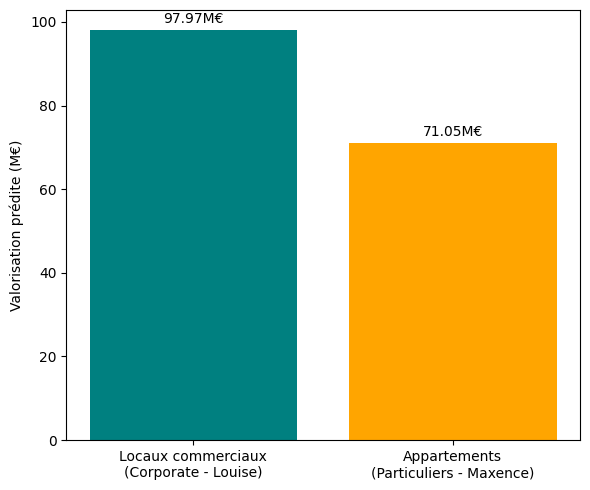

In [41]:
import matplotlib.pyplot as plt
categories = [
    "Locaux commerciaux\n(Corporate - Louise)",
    "Appartements\n(Particuliers - Maxence)"
]
valeurs = [val_corp, val_part]
couleurs = ["teal", "orange"]

plt.figure(figsize=(6, 5))
plt.bar(categories, valeurs, color=couleurs)

plt.ylabel("Valorisation prédite (M€)")


# Affichage des valeurs au-dessus des barres
for i, v in enumerate(valeurs):
    plt.text(i, v + 1, f"{v:.2f}M€", ha="center", va="bottom")

plt.tight_layout()
plt.show()


## Milestone 4 - Classification des données issues du jeu de test

Dans cette partie nous allons labelliser automatiquement les biens immobiliers comme étant :

soit des Appartements
soit des Local industriel. commercial ou assimilé Pour cela nous allons utiliser l'algorithme du KMeans sur le jeu de données partagé par l'entreprise.
Pour que l'algorithme fonctionne, il faut que nous préparions les données en supprimant les dimensions inutiles et en nous concentrant sur le facteur discriminant entre les appartements et les locaux commerciaux : la différence dans le prix au mètre carré tel que nous l'avons vu avant.

In [42]:
# On importe les données dans un dataframe
# 1)télécharger les fichiers
from google.colab import files
uploaded = files.upload()


Saving echantillon_a_classer2.xlsx to echantillon_a_classer2.xlsx


In [43]:
# 2)Charger le fichier Excel dans un DataFrame
df_echantillon = pd.read_excel("echantillon_a_classer2.xlsx")

#Infos générales du l'echantillon
print( df_echantillon.info())
print(f"df_echantillon : {len(df_echantillon)} biens immobiliers")
df_echantillon.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   valeur_fonciere  40 non-null     float64
 1   code_postal      40 non-null     int64  
 2   nom_commune      40 non-null     object 
 3   surface_reelle   40 non-null     int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 1.4+ KB
None
df_echantillon : 40 biens immobiliers


,valeur_fonciere,code_postal,nom_commune,surface_reelle
0,868687.083271,75019,Paris 19e Arrondissement,88
1,452050.762192,75019,Paris 19e Arrondissement,45
2,193088.653587,75019,Paris 19e Arrondissement,21
3,303012.549370,75019,Paris 19e Arrondissement,32
4,149272.200110,75019,Paris 19e Arrondissement,20


On applique les transformations nécessaires. Tout d'abord nous allons calculer le prix au mètre carré en divisant la valeur foncière par la surface. Ensuite nous allons retirer ces colonnes car nous avons déjà l'information qu'elles contiennent dans la dimension prix au mètre carré désormais.

Enfin toutes nos données sont de l'année 2021. Nous allons retirer cette dimension qui ne devrait pas être discriminante dans le regroupement des données.

In [44]:
# On applique les transformations nécessaires.
# crier dataframedf_echantillon_model et calcul du prix au mètre carré
df_echantillon_model = df_echantillon.copy()
df_echantillon_model['prix_m2'] = df_echantillon_model['valeur_fonciere'] / df_echantillon_model['surface_reelle']

# Retirer les colonnes: valeur_fonciere, surface_reelle
df_echantillon_model = df_echantillon_model.drop(columns=["valeur_fonciere", "surface_reelle"])

df_echantillon_model.head()

,code_postal,nom_commune,prix_m2
0,75019,Paris 19e Arrondissement,9871.444128
1,75019,Paris 19e Arrondissement,10045.572493
2,75019,Paris 19e Arrondissement,9194.697790
3,75019,Paris 19e Arrondissement,9469.142168
4,75019,Paris 19e Arrondissement,7463.610005


Nous observons dans les données que nous avons des valeurs différentes de prix au mètre carré pour un même arrondissement (ici le 19ème arrondissement). Il se peut fort que cela soit notre dimension à utiliser pour attribuer les prix au mètre carré les plus élévé dans un département aux locaux commerciaux, et les prix les plus bas aux appartements.

Pour effectuer cette opération, nous allons utiliser l'algorithme du Kmeans qui va rechercher 2 centroïdes à travers les données.

In [45]:
# donc Nous utilisons l’algorithme K-Means pour regrouper automatiquement les biens immobiliers en deux catégories, uniquement en fonction de leur prix au mètre carré

from sklearn.cluster import KMeans

# Sélectionne la colonne prix_m2 pour effectuer un clustering basé uniquement sur le prix au m²
X_classif = df_echantillon_model[['prix_m2']].copy()

# Création du modèle K-Means
kmeans = KMeans(n_clusters=2, random_state=42)

# Entraîner le modèle
kmeans.fit(X_classif )

# Prédire les clusters et les ajouter au dataframe
df_echantillon_model['cluster'] = kmeans.predict(X_classif )

# On vérifie les données de la prédiction:
#  Afficher le nombre de biens dans chaque cluster
print("Nombre de biens dans chaque cluster :")

print(df_echantillon_model['cluster'].value_counts())

Nombre de biens dans chaque cluster :
cluster
1    20
0    20
Name: count, dtype: int64


Supplément : visualisation graphique des clusters

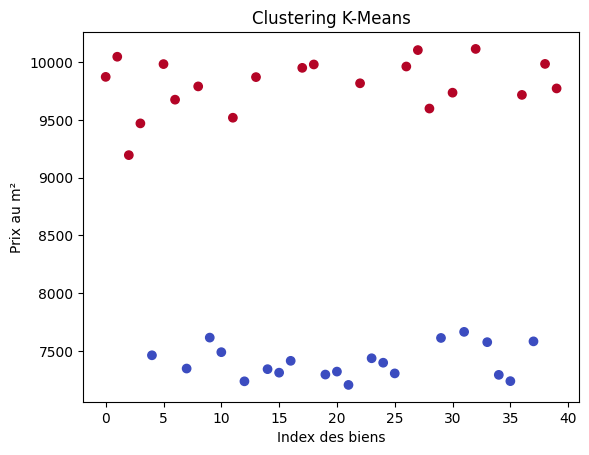

In [46]:
# visualisation graphique des clusters:
import matplotlib.pyplot as plt

plt.scatter(df_echantillon_model.index, df_echantillon_model['prix_m2'], c=df_echantillon_model['cluster'], cmap='coolwarm')
plt.xlabel('Index des biens')
plt.ylabel('Prix au m²')
plt.title('Clustering K-Means')
plt.show()


Nous avons obtenu notre prédiction. Nous pouvons changer les labels et remplacer les valeurs à 0 par Local industriel. commercial ou assimilé et les valeurs à +1 par Appartement.

In [47]:
# Identification des labels : le cluster avec le prix au m² le plus bas => appartements; et le cluster avec le prix au m² le plus élevé =>locaux commerciaux
centers = kmeans.cluster_centers_.flatten()
cluster_appart = np.argmin(centers)  # prix bas →   Appartement
cluster_local = np.argmax(centers)   # prix haut →  local commercial

# Remplacement des labels numériques par les labels métier
df_echantillon_model['type_predit'] = df_echantillon_model['cluster'].map({
    cluster_local: 'Local industriel. commercial ou assimilé',
    cluster_appart: 'Appartement'
})

print("Résultats de la classification :")
print(df_echantillon_model['type_predit'].value_counts())
# Affichage type_predit
df_echantillon_model.head()


Résultats de la classification :
type_predit
Local industriel. commercial ou assimilé    20
Appartement                                 20
Name: count, dtype: int64


,code_postal,nom_commune,prix_m2,cluster,type_predit
0,75019,Paris 19e Arrondissement,9871.444128,1,Local industriel. commercial ou assimilé
1,75019,Paris 19e Arrondissement,10045.572493,1,Local industriel. commercial ou assimilé
2,75019,Paris 19e Arrondissement,9194.697790,1,Local industriel. commercial ou assimilé
3,75019,Paris 19e Arrondissement,9469.142168,1,Local industriel. commercial ou assimilé
4,75019,Paris 19e Arrondissement,7463.610005,0,Appartement


In [48]:
# Affichage des résultats finaux dans le fichier df_echantillon
# Ajouter la colonne 'type_predit' de df_echantillon_model dans df_echantillon
df_echantillon['type_predit'] = df_echantillon_model['type_predit']
df_echantillon


,valeur_fonciere,code_postal,nom_commune,surface_reelle,type_predit
0,868687.083271,75019,Paris 19e Arrondissement,88,Local industriel. commercial ou assimilé
1,452050.762192,75019,Paris 19e Arrondissement,45,Local industriel. commercial ou assimilé
2,193088.653587,75019,Paris 19e Arrondissement,21,Local industriel. commercial ou assimilé
3,303012.549370,75019,Paris 19e Arrondissement,32,Local industriel. commercial ou assimilé
4,149272.200110,75019,Paris 19e Arrondissement,20,Appartement
5,179676.304545,75019,Paris 19e Arrondissement,18,Local industriel. commercial ou assimilé
6,241856.569418,75019,Paris 19e Arrondissement,25,Local industriel. commercial ou assimilé
7,462981.797149,75019,Paris 19e Arrondissement,63,Appartement
8,518819.726233,75019,Paris 19e Arrondissement,53,Local industriel. commercial ou assimilé
9,403670.310822,75019,Paris 19e Arrondissement,53,Appartement


## Milestone 5 - Analyse et présentation des résultats

Mes conclusions sur l'analyse :

Notre modèle de régression linéaire (MAPE de 9,53 %) prédit que le portefeuille corporate de Louise (97,97 M€) est plus valorisé que celui de Maxence (71,05 M€) au 31 décembre 2022. Notre recommandation est de vendre en priorité une partie des actifs corporate pour préserver le potentiel de revalorisation du segment particuliers.

L’algorithme K-means a classé correctement les 40 biens transmis par Louise, soit 20 appartements et 20 locaux commerciaux, ce qui représente un gain de temps significatif.

les limites de l'exercice :

Pour la régression linéaire, le modèle ne capture pas les dynamiques non linéaires du marché, et les données manquent de caractéristiques qualitatives essentielles.

Pour la classification, l’approche repose uniquement sur le prix au m² et a été testée uniquement sur le 9ᵉ arrondissement. De plus, K-means pourrait perdre en pertinence si les prix des différents types de biens venaient à se rapprocher.